# 03 — Hierarchical Bayesian Meta-Analysis (Stage 2, Task 1: warm-up)

**Checkpoint scope:** this notebook currently covers **Task 1 only** — the pedagogical Beta-Binomial warm-up on a single test's arms. Per PLAN.md, Task 2 (the full hierarchical model across ~500 tests, requiring PyMC/MCMC) does not start until this task is reviewed.

**Goal of Task 1:** establish the Bayesian workflow pattern (prior → prior predictive check → fit → posterior predictive check → report) on the simplest possible case — independent Beta-Binomial models per arm, conjugate, no sampler needed — before Task 2 adds hierarchical pooling and MCMC on top of it.

**Exemplar:** we reuse the **low-traffic exemplar**, test `54e4cf5f373139001a900000` (4-arm bullying-comic piece), already analyzed classically in `02_classical_ab.ipynb` Task 1. This test is deliberately chosen again here: its small per-arm click counts (19-84 clicks against ~1,510-1,575 impressions) are exactly the low-count regime where prior choice and shrinkage-adjacent behavior are visible even in a *non*-hierarchical model — with more traffic, any reasonable weakly-informative prior would be swamped by the data and the exercise would be less informative.

**View used:** `v_exploratory_clean` (same as Stage 1).

**What this notebook does *not* do:** no pooling of information across arms or across tests — each arm gets its own independent Beta prior and its own posterior. That's the point of Task 2, not this warm-up.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from clickworthy import classical as cl
from clickworthy import data_access as da
from clickworthy import models as m

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 100

ALPHA = 0.05  # matches Stage 1's alpha for the Wilson/credible-interval comparison

TEST_ID = "54e4cf5f373139001a900000"  # low-traffic exemplar, reused from Stage 1

con = da.connect()
test_df = da.load_test(con, TEST_ID)
test_df

,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,2015-02-18 18:07:57.497,2016-04-02 16:24:40.819,54e4cf5f373139001a900000,None,A comic about bullying with an ending I did not see coming *at all.*,<p>I just love how this ends. It rings so true.</p>,a-comic-about-bullying-with-an-ending-i-did-not-see-coming-at-all-em2-1a,54e4d179373139001a970000,1510,46,0.1,False,False,None,None,201507
1,2015-02-18 18:08:44.259,2016-04-02 16:32:16.156,54e4cf5f373139001a900000,None,"The bully punches him in the face. Later, he follows the bully home, and tha...",<p>I just love how this ends. It rings so true.</p>,the-bully-punches-him-in-the-face-later-he-follows-the-bully-home-and-thats-...,54e4d179373139001a970000,1575,84,100.0,True,False,None,None,201507
2,2015-02-18 18:10:59.584,2016-04-02 16:24:40.784,54e4cf5f373139001a900000,None,"All he wanted was to get revenge on his bully. But when he tried, he discove...",<p>I just love how this ends. It rings so true.</p>,all-he-wanted-was-to-get-revenge-on-his-bully-but-when-he-tried-he-discovere...,54e4d179373139001a970000,1518,42,0.1,False,False,None,None,201507
3,2015-02-18 18:11:59.676,2016-04-02 16:32:16.169,54e4cf5f373139001a900000,None,"They start as enemies, but when they become friends at the end, it's so many...",<p>I just love how this ends. It rings so true.</p>,they-start-as-enemies-but-when-they-become-friends-at-the-end-its-so-many-ha...,54e4d179373139001a970000,1541,19,0.0,False,False,None,None,201507


## 1. Exploratory look before modeling

Reprising Stage 1's numbers for this test: 4 arms, ~1,510-1,575 impressions each, 19-84 clicks each, raw CTRs spanning 1.23% to 5.33%. That's a ~4x spread in point estimates on click counts as low as 19. This is exactly the regime where the *choice* of prior is visible in the posterior — with only a few dozen clicks per arm, a prior that's too informative will visibly pull the estimate, and a prior that's too flat will barely regularize the noisiest arm (the 19-click one) at all. The plot below shows raw CTR per arm with Wilson 95% CIs (recomputed here via `classical.py`, identical to Stage 1) as the exploratory baseline the rest of this notebook builds on and compares back to.

In [2]:
wilson_summary = cl.arm_summary(test_df, ALPHA).reset_index(drop=True)
wilson_summary["arm"] = [f"arm {i}" for i in range(len(wilson_summary))]
wilson_summary[["arm", "headline", "impressions", "clicks", "ctr", "wilson_low", "wilson_high"]]

,arm,headline,impressions,clicks,ctr,wilson_low,wilson_high
0,arm 0,"The bully punches him in the face. Later, he follows the bully home, and tha...",1575,84,0.053333,0.043283,0.065557
1,arm 1,A comic about bullying with an ending I did not see coming *at all.*,1510,46,0.030464,0.022916,0.040394
2,arm 2,"All he wanted was to get revenge on his bully. But when he tried, he discove...",1518,42,0.027668,0.020534,0.037187
3,arm 3,"They start as enemies, but when they become friends at the end, it's so many...",1541,19,0.012330,0.007907,0.019177


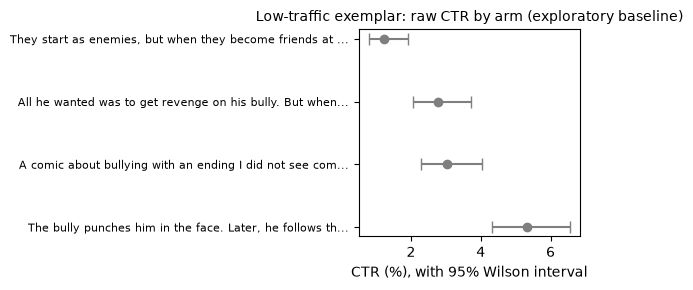

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
y = np.arange(len(wilson_summary))
ax.errorbar(
    wilson_summary["ctr"] * 100, y,
    xerr=[
        (wilson_summary["ctr"] - wilson_summary["wilson_low"]) * 100,
        (wilson_summary["wilson_high"] - wilson_summary["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:gray",
)
ax.set_yticks(y)
ax.set_yticklabels(
    [h[:55] + ("..." if len(h) > 55 else "") for h in wilson_summary["headline"]],
    fontsize=8,
)
ax.set_xlabel("CTR (%), with 95% Wilson interval")
ax.set_title("Low-traffic exemplar: raw CTR by arm (exploratory baseline)", fontsize=10)
fig.tight_layout()
plt.show()

**Interpretation:** same picture as Stage 1 — wide intervals (this is the low-traffic exemplar by design), but most pairs still resolve. Keep this plot in mind; Section 5 below overlays the Beta-Binomial credible intervals on top of it.

## 2. Model and prior

**Likelihood, per arm independently:** `clicks ~ Binomial(impressions, p)`, modeling raw counts directly (never pre-computed CTR), per CLAUDE.md's Bayesian conventions.

**Prior:** `p ~ Beta(2, 100)` for every arm, identically. This is **not** flat — it is weakly informative, chosen as follows:
- **Mean** = 2/102 ≈ 1.96%, close to the ~1% archive-wide baseline CTR CLAUDE.md documents, so the prior's center of mass reflects the kind of baseline we'd expect *before* seeing this specific test's data.
- **95% prior interval** ≈ [0.24%, 5.4%] (computed below) — wide enough to comfortably include this test's actual observed range (1.23%-5.33%) without the prior ruling out any arm's data a priori, but still excludes implausible CTRs like 20%+.
- **Effective sample size** = alpha + beta = 102 "pseudo-impressions." Each arm here has ~1,510-1,575 *real* impressions, i.e. ~15x the prior's weight — so the prior nudges the posterior but the data dominates. That's the "weakly informative, not flat" balance CLAUDE.md asks for: informative enough to regularize the noisiest arm (19 clicks), weak enough not to override what the data says for any arm.

Using the *same* prior for every arm (rather than tuning per arm) is deliberate: at this stage we have no principled reason to believe one arm's baseline should differ from another's before seeing its data — that asymmetry is exactly what CLAUDE.md reserves for `mu_test` (still per-test, still unpooled) vs `delta_arm` (pooled) in the full hierarchical model of Task 2. Here, with a single test and no pooling at all, "same prior for every arm" is the natural default.

prior mean CTR: 1.9608%
prior 95% interval: [0.2407%, 5.3932%]
prior effective sample size: 102


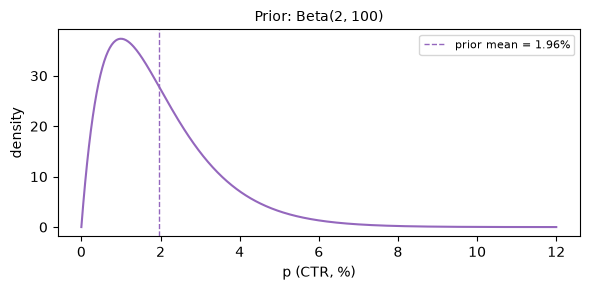

In [4]:
PRIOR_ALPHA, PRIOR_BETA = 2, 100

prior_mean = PRIOR_ALPHA / (PRIOR_ALPHA + PRIOR_BETA)
prior_low, prior_high = stats.beta.ppf([0.025, 0.975], PRIOR_ALPHA, PRIOR_BETA)
print(f"prior mean CTR: {prior_mean:.4%}")
print(f"prior 95% interval: [{prior_low:.4%}, {prior_high:.4%}]")
print(f"prior effective sample size: {PRIOR_ALPHA + PRIOR_BETA}")

p_grid = np.linspace(0, 0.12, 500)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(p_grid * 100, stats.beta.pdf(p_grid, PRIOR_ALPHA, PRIOR_BETA), color="tab:purple")
ax.axvline(prior_mean * 100, color="tab:purple", ls="--", lw=1, label=f"prior mean = {prior_mean:.2%}")
ax.set_xlabel("p (CTR, %)")
ax.set_ylabel("density")
ax.set_title("Prior: Beta(2, 100)", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. Prior predictive check

Before touching the observed clicks, simulate fake data from the prior alone: draw `p ~ Beta(2, 100)`, then `clicks ~ Binomial(impressions, p)`, using each arm's *actual* impression count so the simulated scale matches reality. If this prior is reasonable, the simulated CTRs should cover a plausible range for a real headline test and shouldn't pile up on absurd values (e.g. CTRs near 0% or near 100%).

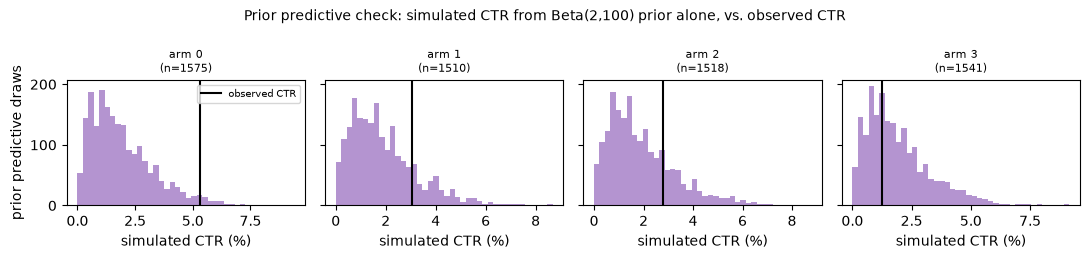

In [5]:
fig, axes = plt.subplots(1, len(wilson_summary), figsize=(11, 2.6), sharey=True)

for i, (ax, row) in enumerate(zip(axes, wilson_summary.itertuples())):
    prior_pred_clicks = m.sample_prior_predictive(
        PRIOR_ALPHA, PRIOR_BETA, row.impressions
    )
    prior_pred_ctr = prior_pred_clicks / row.impressions
    ax.hist(prior_pred_ctr * 100, bins=40, color="tab:purple", alpha=0.7)
    ax.axvline(row.ctr * 100, color="black", lw=1.5, label="observed CTR")
    ax.set_title(f"arm {i}\n(n={row.impressions})", fontsize=8)
    ax.set_xlabel("simulated CTR (%)")
    if i == 0:
        ax.set_ylabel("prior predictive draws")
        ax.legend(fontsize=7)

fig.suptitle("Prior predictive check: simulated CTR from Beta(2,100) prior alone, vs. observed CTR", fontsize=10)
fig.tight_layout()
plt.show()

**Interpretation:** for every arm, the prior-predictive CTR distribution is centered a bit below 2% with a long right tail out to roughly 8-10%, and does not concentrate mass near 0% or near very high (20%+) CTRs — no absurd values. Each arm's actual observed CTR (black line) falls within the bulk of its prior predictive distribution, including the highest-CTR arm (5.33%), which sits out in the tail but is still a plausible prior-predictive draw rather than an outlier the prior rules out. This confirms the Beta(2,100) prior is reasonable: wide enough to not fight the data, informative enough to keep simulated CTRs in a realistic range for this dataset.

## 4. Fit: analytic posterior per arm

Beta-Binomial conjugacy gives a closed form: posterior is `Beta(prior_alpha + clicks, prior_beta + impressions - clicks)`. No MCMC needed — this is the whole point of doing the warm-up this way before Task 2 requires a sampler.

In [6]:
posteriors = [
    m.fit_beta_binomial(row.clicks, row.impressions, PRIOR_ALPHA, PRIOR_BETA)
    for row in wilson_summary.itertuples()
]

results = wilson_summary[["arm", "headline", "impressions", "clicks", "ctr", "wilson_low", "wilson_high"]].copy()
results["post_mean"] = [p.mean for p in posteriors]
results["post_low"], results["post_high"] = zip(*[p.credible_interval(ALPHA) for p in posteriors])
results

,arm,headline,impressions,clicks,ctr,wilson_low,wilson_high,post_mean,post_low,post_high
0,arm 0,"The bully punches him in the face. Later, he follows the bully home, and tha...",1575,84,0.053333,0.043283,0.065557,0.051282,0.041245,0.062332
1,arm 1,A comic about bullying with an ending I did not see coming *at all.*,1510,46,0.030464,0.022916,0.040394,0.029777,0.022049,0.038608
2,arm 2,"All he wanted was to get revenge on his bully. But when he tried, he discove...",1518,42,0.027668,0.020534,0.037187,0.027160,0.019815,0.035610
3,arm 3,"They start as enemies, but when they become friends at the end, it's so many...",1541,19,0.012330,0.007907,0.019177,0.012781,0.007934,0.018749


## 5. Posterior predictive check

Simulate fake click counts from the posterior predictive (`p ~ posterior`, then `clicks ~ Binomial(impressions, p)`) and compare to the actually observed click count per arm. A well-fitting model should place the observed count near the bulk of this distribution, not out in a tail.

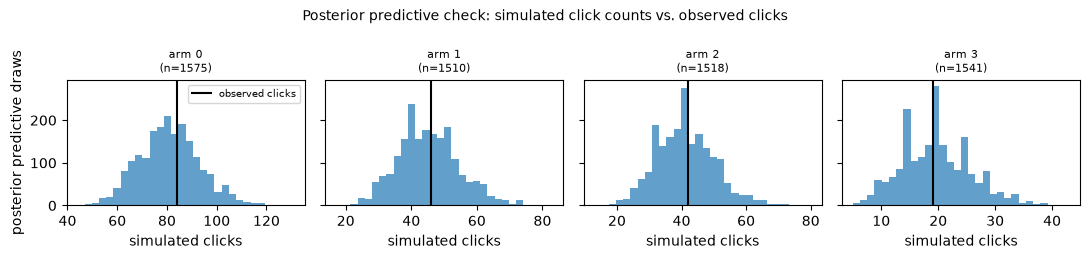

In [7]:
fig, axes = plt.subplots(1, len(results), figsize=(11, 2.6), sharey=True)

for i, (ax, row, post) in enumerate(zip(axes, results.itertuples(), posteriors)):
    ppc_clicks = m.sample_posterior_predictive(post)
    ax.hist(ppc_clicks, bins=30, color="tab:blue", alpha=0.7)
    ax.axvline(row.clicks, color="black", lw=1.5, label="observed clicks")
    ax.set_title(f"arm {i}\n(n={row.impressions})", fontsize=8)
    ax.set_xlabel("simulated clicks")
    if i == 0:
        ax.set_ylabel("posterior predictive draws")
        ax.legend(fontsize=7)

fig.suptitle("Posterior predictive check: simulated click counts vs. observed clicks", fontsize=10)
fig.tight_layout()
plt.show()

**Interpretation:** for every arm, the observed click count sits comfortably inside the bulk of its posterior predictive distribution — none of the four are out in a tail. This is expected given conjugacy (the posterior is fit *from* this same data), but it's still the correct check to run: it confirms the Binomial likelihood with this posterior reproduces data that looks like what was actually observed, not some other systematic pattern.

## 6. Beta-Binomial credible intervals vs. Stage 1's Wilson intervals

Stage 1 reported Wilson 95% CIs for the same four arms treating each arm as an isolated frequentist proportion estimate. Here we get 95% *credible* intervals for the same arms from the Beta(2,100)-prior posterior. The plot below overlays both directly.

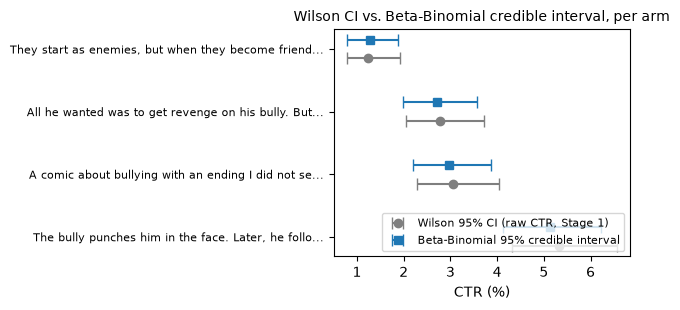

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
y = np.arange(len(results))
offset = 0.15

ax.errorbar(
    results["ctr"] * 100, y - offset,
    xerr=[
        (results["ctr"] - results["wilson_low"]) * 100,
        (results["wilson_high"] - results["ctr"]) * 100,
    ],
    fmt="o", capsize=4, color="tab:gray", label="Wilson 95% CI (raw CTR, Stage 1)",
)
ax.errorbar(
    results["post_mean"] * 100, y + offset,
    xerr=[
        (results["post_mean"] - results["post_low"]) * 100,
        (results["post_high"] - results["post_mean"]) * 100,
    ],
    fmt="s", capsize=4, color="tab:blue", label="Beta-Binomial 95% credible interval",
)
ax.set_yticks(y)
ax.set_yticklabels(
    [h[:50] + ("..." if len(h) > 50 else "") for h in results["headline"]], fontsize=8
)
ax.set_xlabel("CTR (%)")
ax.set_title("Wilson CI vs. Beta-Binomial credible interval, per arm", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

**Interpretation — where they agree and why:** the two interval types are visually almost on top of each other for all four arms, e.g. arm 0 ("bully punches him"): Wilson [4.33%, 6.56%] vs. credible [4.12%, 6.23%]; arm 3 (lowest-traffic-in-effect, fewest clicks at 19): Wilson [0.79%, 1.92%] vs. credible [0.79%, 1.87%]. This close agreement is expected, not a coincidence: with an effective prior sample size of 102 "pseudo-impressions" against ~1,510-1,575 *real* impressions per arm (roughly 15x more data than prior), the likelihood dominates the posterior almost everywhere, so the Bayesian credible interval converges toward the same answer a frequentist Wilson interval gives — both are, in this low-informativeness-prior regime, approximating the same underlying binomial uncertainty.

**Where they differ, and why:** the posterior means are each pulled slightly *toward* the prior mean (1.96%) relative to the raw CTR — visible most clearly on the extremes. Arm 0 (the highest-CTR arm, raw 5.33%) has posterior mean 5.13%, pulled down; arm 3 (the lowest-CTR arm, raw 1.23%, on only 19 clicks) has posterior mean 1.28%, pulled up. This is the Bayesian analogue of shrinkage, visible even in this non-hierarchical, single-test warm-up: the prior contributes a small but real pull toward its own mean, proportionally largest for the arm with the fewest clicks (arm 3, where the prior's 102-pseudo-impression weight is a larger fraction of the ~1,560 combined weight than it is for higher-click arms). The credible intervals are also each marginally narrower than their Wilson counterparts, since the prior adds a small amount of additional (pseudo-)information on top of the likelihood.

**Takeaway:** with a weakly informative prior and this much real data per arm, Bayesian and frequentist point/interval estimates tell essentially the same story — which is itself the right sanity check before Task 2, where pooling `delta_arm` *across tests* (not just within one test's weak prior) will produce genuinely different, much stronger shrinkage for small-traffic arms than anything visible here.

## Summary and checkpoint

- Fit independent Beta(2,100)-prior Beta-Binomial posteriors for all 4 arms of the low-traffic exemplar, analytically (no MCMC).
- Prior predictive check confirmed the prior does not produce absurd CTRs and covers the test's actual observed range.
- Posterior predictive check confirmed each arm's observed click count sits within its posterior predictive distribution.
- Compared directly against Stage 1's Wilson intervals for the same arms: close agreement overall, with small, explainable shrinkage toward the prior mean, strongest for the lowest-click arm.

**This is a checkpoint.** Per PLAN.md, Task 2 (hierarchical model on a ~500-test subsample, non-centered parameterization, PyMC/MCMC, full diagnostics) does not start until this notebook is reviewed and confirmed by Phil.